## Part B: Data Analysis & Testing Tasks

In [63]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
from scipy import stats
import statsmodels.api as sm

In [64]:
df = pd.read_csv('spread_locator_dataset - spread_locator_dataset.csv.csv')
df

,transaction_id,customer_id,transaction_amount,transaction_date,transaction_count,region,transaction_status
0,e98aa092-3770-4fdb-9502-5b5a6a244811,CUST2824,3821.34,2023-01-26,3,North,Fail
1,11ba6918-dba0-41e5-96cf-f5a7b95f0103,CUST1409,2781.84,2023-01-28,0,East,Fail
2,82b7654b-6eb7-4579-89a0-1a9edec0a7bb,CUST5506,4120.97,2023-01-28,0,South,Fail
3,f7166574-f400-4d53-b526-0b11f6619ddf,CUST5012,6383.78,2023-01-18,2,South,Success
4,8632fe26-b507-4068-9c68-1b2fa04fecb3,CUST4657,2651.61,2023-01-04,4,North,Success
...,...,...,...,...,...,...,...
215,10c2a8f2-89d0-485c-bf8f-9508d32a02fc,CUST5563,4356.76,2023-01-12,2,South,Fail
216,5618814b-f7e2-424d-9617-9fc8d8643370,CUST8579,2025.53,2023-01-29,6,South,Fail
217,5636c9e7-9d54-4654-9c89-fdf31be87d96,CUST5092,2648.08,2023-01-30,1,West,Fail
218,6ba09450-a455-4983-bbad-3dad292cc839,CUST2235,2338.62,2023-01-26,3,North,Success


## Bernoulli Distribution

In [65]:
occurred = (df['transaction_status'] == 'Success').astype(int) # Success = 1, Failure = 0

p = occurred.mean()
print("Probability of Success:", p)   #Success probability calculate ho rahi hai.

Probability of Success: 0.44545454545454544


## Binomial Distribution

In [66]:
n = 10 #Number of trials for Binomial distribution

binomial = np.random.binomial(n, p, 1000) # Generate 1000 Binomial samples using n trials and probability p
print(binomial[:10])

[4 6 4 6 4 3 2 4 2 4]


## Poisson Distribution

In [67]:
lam = df['transaction_count'].mean() # Calculate average daily transaction count (Poisson rate parameter λ)

poisson = np.random.poisson(lam, 1000) # Generate 1000 samples from Poisson distribution

print("Lambda:", lam)

Lambda: 2.8545454545454545


## Log-Normal distributions

In [68]:
amounts = df['transaction_amount'] 
shape, loc, scale = stats.lognorm.fit(amounts)

print("Log-Normal Distribution :")
print("Shape =", shape)
print("Location =", loc)
print("Scale =", scale)

Log-Normal Distribution :
Shape = 0.5416831487801056
Location = 333.7722748609052
Scale = 2604.740667049811


## Power-Law Distribution

In [69]:
params = stats.powerlaw.fit(amounts)

print("Power-Law Parameters:")
print(params)

Power-Law Parameters:
(np.float64(0.41232325172331613), np.float64(804.4199999999998), np.float64(19658.420000000006))


## Q-Q (Quantile-Quantile) Plot

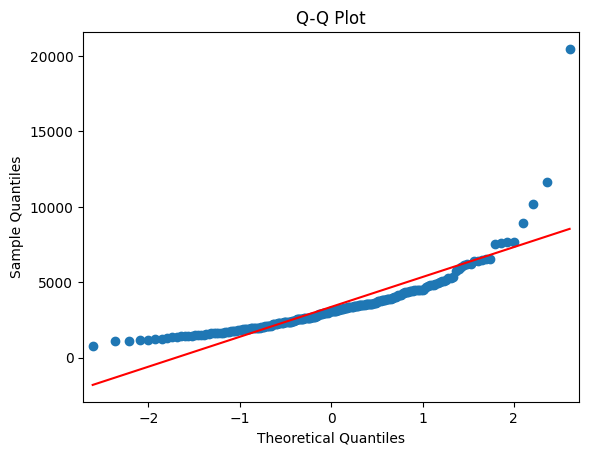

In [70]:
# Generate Q-Q Plot to assess normality of transaction amounts
sm.qqplot(amounts, line='s')
plt.title("Q-Q Plot")
plt.show()

## Box-Cox Transformation

In [71]:
positive = amounts[amounts > 0] # Select only positive transaction amounts

transformed, lam = stats.boxcox(positive) # Apply Box-Cox Transformation
print("Lambda:", lam)

Lambda: -0.18083390743966327


## Z-Score & Probability

In [72]:
z = stats.zscore(amounts) # Calculate Z-scores for transaction amounts

prob = 1 - stats.norm.cdf(5000, amounts.mean(), amounts.std()) # Calculate probability of transaction amount being greater than 5000

print("Probability:", prob)

Probability: 0.20517209567554384


## PDF & CDF

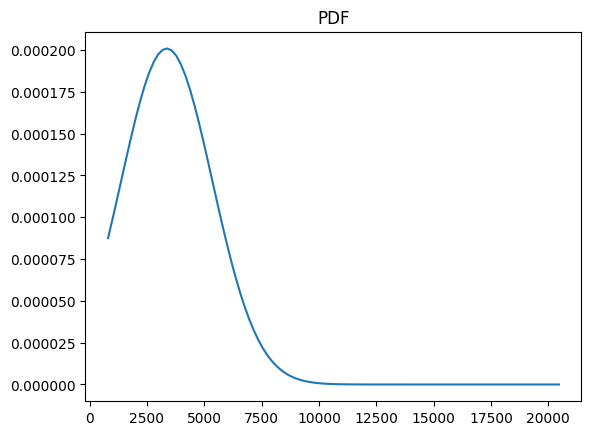

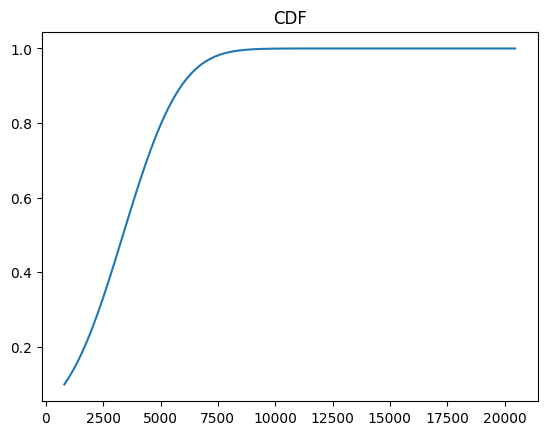

In [73]:
x = np.linspace(amounts.min(), amounts.max(), 100) # Create a range of values from minimum to maximum transaction amount

pdf = stats.norm.pdf(x, amounts.mean(), amounts.std()) # Calculate Normal Distribution PDF

cdf = stats.norm.cdf(x, amounts.mean(), amounts.std()) # Calculate Normal Distribution CDF

# Plot PDF curve
plt.plot(x, pdf)
plt.title("PDF")
plt.show()

# Plot CDF curve
plt.plot(x, cdf)
plt.title("CDF")
plt.show()

## Conclusion

• Bernoulli Distribution → Calculated the probability of successful transactions.

• Binomial Distribution → Simulated multiple transaction outcomes.

• Poisson Distribution → Modeled the number of transactions.

• Log-Normal & Power-Law Distributions → Analyzed transaction amounts.

• Q-Q Plot → Checked whether the data follows a normal distribution.

• Box-Cox Transformation → Reduced skewness and improved normality.

• Z-Score → Measured how far values are from the mean.

• PDF & CDF → Visualized probability distributions.